# Acrobot (2-DoF manipulator) — vanilla receding-horizon MPC for reach-avoid


In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import casadi as ca
from matplotlib.patches import Rectangle
from acrobot_inverse_kinematics import inverse_kinematics
from functional import BetterColor

# ── Physical parameters ───────────────────────────────────────────────────────
m1, m2 = 1.0, 1.0
l1, l2 = 4.0, 4.0
lc1, lc2 = 2.0, 2.0
I1, I2 = 0.02, 0.02
g_grav = 9.81


# ── Sets in output (y) space ──────────────────────────────────────────────────
#   safe  psi(y) >= 0 : inside safe region
#   target phi(y) <= 0 : inside target region
def psi_y_np(y1, y2):
    return -((4 * (y1 - 2) - 2 * y2**3) ** 2) + 0.8 * y2**3 + 10


def phi_y_np(y1, y2):
    return ((y1 - 2 - 3.5) ** 2 / 1.2**2) + ((y2 - 1.9) ** 2 / 0.4**2) - 2


def h_np(x):
    """End-effector position from joint state x = [q1, q2, dq1, dq2]."""
    q1, q2 = x[0], x[1]
    return np.array(
        [l1 * np.cos(q1) + l2 * np.cos(q1 + q2), l1 * np.sin(q1) + l2 * np.sin(q1 + q2)]
    )


def psi_x_np(x):
    y = h_np(x)
    return psi_y_np(y[0], y[1])


def phi_x_np(x):
    y = h_np(x)
    return phi_y_np(y[0], y[1])


# Vectorised versions (x is (4,N))
def psi_x_vec(x):
    q1, q2 = x[0], x[1]
    y1v = l1 * np.cos(q1) + l2 * np.cos(q1 + q2)
    y2v = l1 * np.sin(q1) + l2 * np.sin(q1 + q2)
    return psi_y_np(y1v, y2v)


def phi_x_vec(x):
    q1, q2 = x[0], x[1]
    y1v = l1 * np.cos(q1) + l2 * np.cos(q1 + q2)
    y2v = l1 * np.sin(q1) + l2 * np.sin(q1 + q2)
    return phi_y_np(y1v, y2v)


# ── Numpy RHS (used inside DOP853 integrator) ─────────────────────────────────
def acrobot_rhs_np(t, x_, u_):
    q1, q2, dq1, dq2 = x_
    M11 = I1 + I2 + m1 * lc1**2 + m2 * (l1**2 + lc2**2 + 2 * l1 * lc2 * np.cos(q2))
    M12 = m2 * (lc2**2 + l1 * lc2 * np.cos(q2)) + I2
    M_mat = np.array([[M11, M12], [M12, m2 * lc2**2 + I2]])
    C_mat = np.array(
        [
            [
                -m2 * l1 * lc2 * np.sin(q2) * dq2,
                -m2 * l1 * lc2 * np.sin(q2) * (dq1 + dq2),
            ],
            [m2 * l1 * lc2 * np.sin(q2) * dq1, 0.0],
        ]
    )
    G_vec = np.array(
        [
            (m1 * g_grav * lc1 + m2 * g_grav * l1) * np.cos(q1)
            + m2 * g_grav * lc2 * np.cos(q1 + q2),
            m2 * g_grav * lc2 * np.cos(q1 + q2),
        ]
    )
    qdot = np.array([dq1, dq2])
    qddot = np.linalg.solve(M_mat, -C_mat @ qdot - G_vec + np.asarray(u_))
    return [dq1, dq2, qddot[0], qddot[1]]


TARGET_POS = np.array([5.8, 1.9])  # centre of target ellipse in y-space
print(f"System ready. l1={l1}, l2={l2}, max reach={l1+l2}")
print(f"Target centre (y-space): {TARGET_POS}")

System ready. l1=4.0, l2=4.0, max reach=8.0
Target centre (y-space): [5.8 1.9]


In [2]:
# ── CasADi MPC formulation ────────────────────────────────────────────────────
dt_mpc = 0.01  # MPC discretisation step [s]
N_hor = 20  # prediction horizon (steps)
u_max = 500.0  # torque bound [N·m]

# ── CasADi dynamics ───────────────────────────────────────────────────────────
xc = ca.MX.sym("x", 4)
uc = ca.MX.sym("u", 2)


def acrobot_ca(x, u):
    q1, q2, dq1, dq2 = x[0], x[1], x[2], x[3]
    M11 = I1 + I2 + m1 * lc1**2 + m2 * (l1**2 + lc2**2 + 2 * l1 * lc2 * ca.cos(q2))
    M12 = m2 * (lc2**2 + l1 * lc2 * ca.cos(q2)) + I2
    M_ca = ca.vertcat(ca.horzcat(M11, M12), ca.horzcat(M12, m2 * lc2**2 + I2))
    C_ca = ca.vertcat(
        ca.horzcat(
            -m2 * l1 * lc2 * ca.sin(q2) * dq2, -m2 * l1 * lc2 * ca.sin(q2) * (dq1 + dq2)
        ),
        ca.horzcat(m2 * l1 * lc2 * ca.sin(q2) * dq1, ca.DM(0.0)),
    )
    G_ca = ca.vertcat(
        (m1 * g_grav * lc1 + m2 * g_grav * l1) * ca.cos(q1)
        + m2 * g_grav * lc2 * ca.cos(q1 + q2),
        m2 * g_grav * lc2 * ca.cos(q1 + q2),
    )
    qdot = ca.vertcat(dq1, dq2)
    qddot = ca.solve(M_ca, -C_ca @ qdot - G_ca + u)
    return ca.vertcat(dq1, dq2, qddot[0], qddot[1])


rhs_ca = ca.Function("f", [xc, uc], [acrobot_ca(xc, uc)])


def rk4_ca(x, u):
    k1 = rhs_ca(x, u)
    k2 = rhs_ca(x + dt_mpc / 2 * k1, u)
    k3 = rhs_ca(x + dt_mpc / 2 * k2, u)
    k4 = rhs_ca(x + dt_mpc * k3, u)
    return x + (dt_mpc / 6) * (k1 + 2 * k2 + 2 * k3 + k4)


def safe_ca(x):
    y1v = l1 * ca.cos(x[0]) + l2 * ca.cos(x[0] + x[1])
    y2v = l1 * ca.sin(x[0]) + l2 * ca.sin(x[0] + x[1])
    return -((4 * (y1v - 2) - 2 * y2v**3) ** 2) + 0.8 * y2v**3 + 10


def target_ca(x):
    y1v = l1 * ca.cos(x[0]) + l2 * ca.cos(x[0] + x[1])
    y2v = l1 * ca.sin(x[0]) + l2 * ca.sin(x[0] + x[1])
    return ((y1v - 2 - 3.8) ** 2 / 1.2**2) + ((y2v - 1.9) ** 2 / 0.4**2) - 1


def h_ca(x):
    return ca.vertcat(
        l1 * ca.cos(x[0]) + l2 * ca.cos(x[0] + x[1]),
        l1 * ca.sin(x[0]) + l2 * ca.sin(x[0] + x[1]),
    )


_IPOPT_OPTS = {
    "ipopt.print_level": 0,
    "print_time": 0,
    "ipopt.max_iter": 500,
    "ipopt.tol": 1e-4,
    "ipopt.acceptable_tol": 1e-3,
}


def solve_mpc(x0_val, U_warm=None):
    """
    Solve the N_hor-step reach-avoid MPC from x0_val.

    Hard constraints
    ----------------
    * safe_ca(x_k) >= 0  for k = 0 … N_hor   (stay safe)
    * target_ca(x_N) <= 0                     (terminal state inside target)

    Returns
    -------
    feasible : bool
    U_opt    : ndarray shape (2, N_hor), or None if infeasible
    """
    opti = ca.Opti()
    X = opti.variable(4, N_hor + 1)
    U = opti.variable(2, N_hor)

    x0_np = np.asarray(x0_val, dtype=float).flatten()
    opti.subject_to(X[:, 0] == x0_np)

    for k in range(N_hor):
        opti.subject_to(X[:, k + 1] == rk4_ca(X[:, k], U[:, k]))
        opti.subject_to(safe_ca(X[:, k]) >= 0)
    opti.subject_to(safe_ca(X[:, N_hor]) >= 0)
    opti.subject_to(target_ca(X[:, N_hor]) <= 0)
    opti.subject_to(opti.bounded(-u_max, U[0, :], u_max))
    opti.subject_to(opti.bounded(-u_max, U[1, :], u_max))

    tgt = ca.DM(TARGET_POS)
    Q_y = ca.DM([[5.0, 0], [0, 5.0]])
    Qf_y = ca.DM([[50.0, 0], [0, 50.0]])
    R_u = ca.DM([[0.001, 0], [0, 0.001]])
    cost = 0
    for k in range(N_hor):
        dy = h_ca(X[:, k]) - tgt
        cost += dy.T @ Q_y @ dy + U[:, k].T @ R_u @ U[:, k]
    dy_N = h_ca(X[:, N_hor]) - tgt
    cost += dy_N.T @ Qf_y @ dy_N
    opti.minimize(cost)

    # Warm start
    if U_warm is not None:
        opti.set_initial(U, U_warm)
        X_ws = np.zeros((4, N_hor + 1))
        X_ws[:, 0] = x0_np
        for k in range(N_hor):
            X_ws[:, k + 1] = np.asarray(rk4_ca(X_ws[:, k], U_warm[:, k])).flatten()
        opti.set_initial(X, X_ws)
    else:
        # Linear interpolation warm start
        x_tgt_full = np.array([np.arctan2(TARGET_POS[1], TARGET_POS[0]), 0.0, 0.0, 0.0])
        X_ws = np.array(
            [
                (1 - k / N_hor) * x0_np + (k / N_hor) * x_tgt_full
                for k in range(N_hor + 1)
            ]
        ).T
        opti.set_initial(X, X_ws)

    opti.solver("ipopt", _IPOPT_OPTS)
    try:
        sol = opti.solve()
        U_opt = np.asarray(sol.value(U))
        return True, U_opt
    except:
        return False, None


print(f"MPC ready: N_hor={N_hor}, dt={dt_mpc} s, u_bound=±{u_max} N·m")

MPC ready: N_hor=20, dt=0.01 s, u_bound=±500.0 N·m


In [3]:
# ── Sample the state space via output-space + inverse kinematics ──────────────
# (same seed as other notebooks, sampling in y-space then mapping to x via IK)
N_samples = 2000
N_candidates_max = 100
np.random.seed(42)

# Sample end-effector positions in the safe-set region
y1_samp = np.random.uniform(-1.0, 5.5, N_samples)
y2_samp = np.random.uniform(-4.0, 3.1, N_samples)

# Build x_samples via IK (elbow-up solution); set qdot=0
x_list = []
for i in range(N_samples):
    r2 = y1_samp[i] ** 2 + y2_samp[i] ** 2
    if r2 > (l1 + l2) ** 2 or r2 < 1e-4:
        x_list.append([np.nan] * 4)
        continue
    try:
        (q1, q2), _ = inverse_kinematics(y1_samp[i], y2_samp[i], l1, l2)
        if not (np.isfinite(q1) and np.isfinite(q2)):
            x_list.append([np.nan] * 4)
        else:
            x_list.append([q1, q2, 0.0, 0.0])
    except Exception:
        x_list.append([np.nan] * 4)

x_samples = np.array(x_list).T  # (4, N_samples)
valid_ik = np.all(np.isfinite(x_samples), axis=0)

psi_vals = np.where(valid_ik, psi_x_vec(x_samples), -np.inf)
phi_vals = np.where(valid_ik, phi_x_vec(x_samples), -np.inf)

# Step 1: candidates = safe AND outside target (first N_candidates_max)
candidate_mask = (psi_vals >= 0) & (phi_vals > 0)
candidate_idx = np.where(candidate_mask)[0][:N_candidates_max]
print(f"Total samples : {N_samples}")
print(f"Candidates (safe & outside target, capped): {len(candidate_idx)}")

# Step 2: parallel MPC feasibility check
from joblib import Parallel, delayed


def _check_one(idx):
    ok, _ = solve_mpc(x_samples[:, idx])
    return idx, ok


print(
    f"\nChecking MPC feasibility ({len(candidate_idx)} candidates, "
    f"N_hor={N_hor}, dt={dt_mpc}s) ..."
)

results = Parallel(n_jobs=-1, prefer="processes", verbose=5)(
    delayed(_check_one)(idx) for idx in candidate_idx
)

mpc_feasible_idx = np.array([idx for idx, ok in results if ok])
mpc_infeasible_idx = np.array([idx for idx, ok in results if not ok])

n_c = len(candidate_idx)
print(
    f"\nMPC feasible:   {len(mpc_feasible_idx):3d} / {n_c}  "
    f"({100*len(mpc_feasible_idx)/n_c:.1f}%)"
)
print(
    f"MPC infeasible: {len(mpc_infeasible_idx):3d} / {n_c}  "
    f"({100*len(mpc_infeasible_idx)/n_c:.1f}%)"
)

Total samples : 2000
Candidates (safe & outside target, capped): 100

Checking MPC feasibility (100 candidates, N_hor=20, dt=0.01s) ...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public Lic

[Parallel(n_jobs=-1)]: Done  52 tasks      | elapsed:    6.5s



MPC feasible:    50 / 100  (50.0%)
MPC infeasible:  50 / 100  (50.0%)


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   13.2s finished


In [4]:
# determine the bound for the feasible samples in x-space
x1_max = np.nanmax(x_samples[0, mpc_feasible_idx])
x1_min = np.nanmin(x_samples[0, mpc_feasible_idx])
x2_max = np.nanmax(x_samples[1, mpc_feasible_idx])
x2_min = np.nanmin(x_samples[1, mpc_feasible_idx])
print(f"x1 range: [{x1_min:.2f}, {x1_max:.2f}]")
print(f"x2 range: [{x2_min:.2f}, {x2_max:.2f}]")

x1 range: [-1.30, -0.63]
x2 range: [2.02, 2.78]


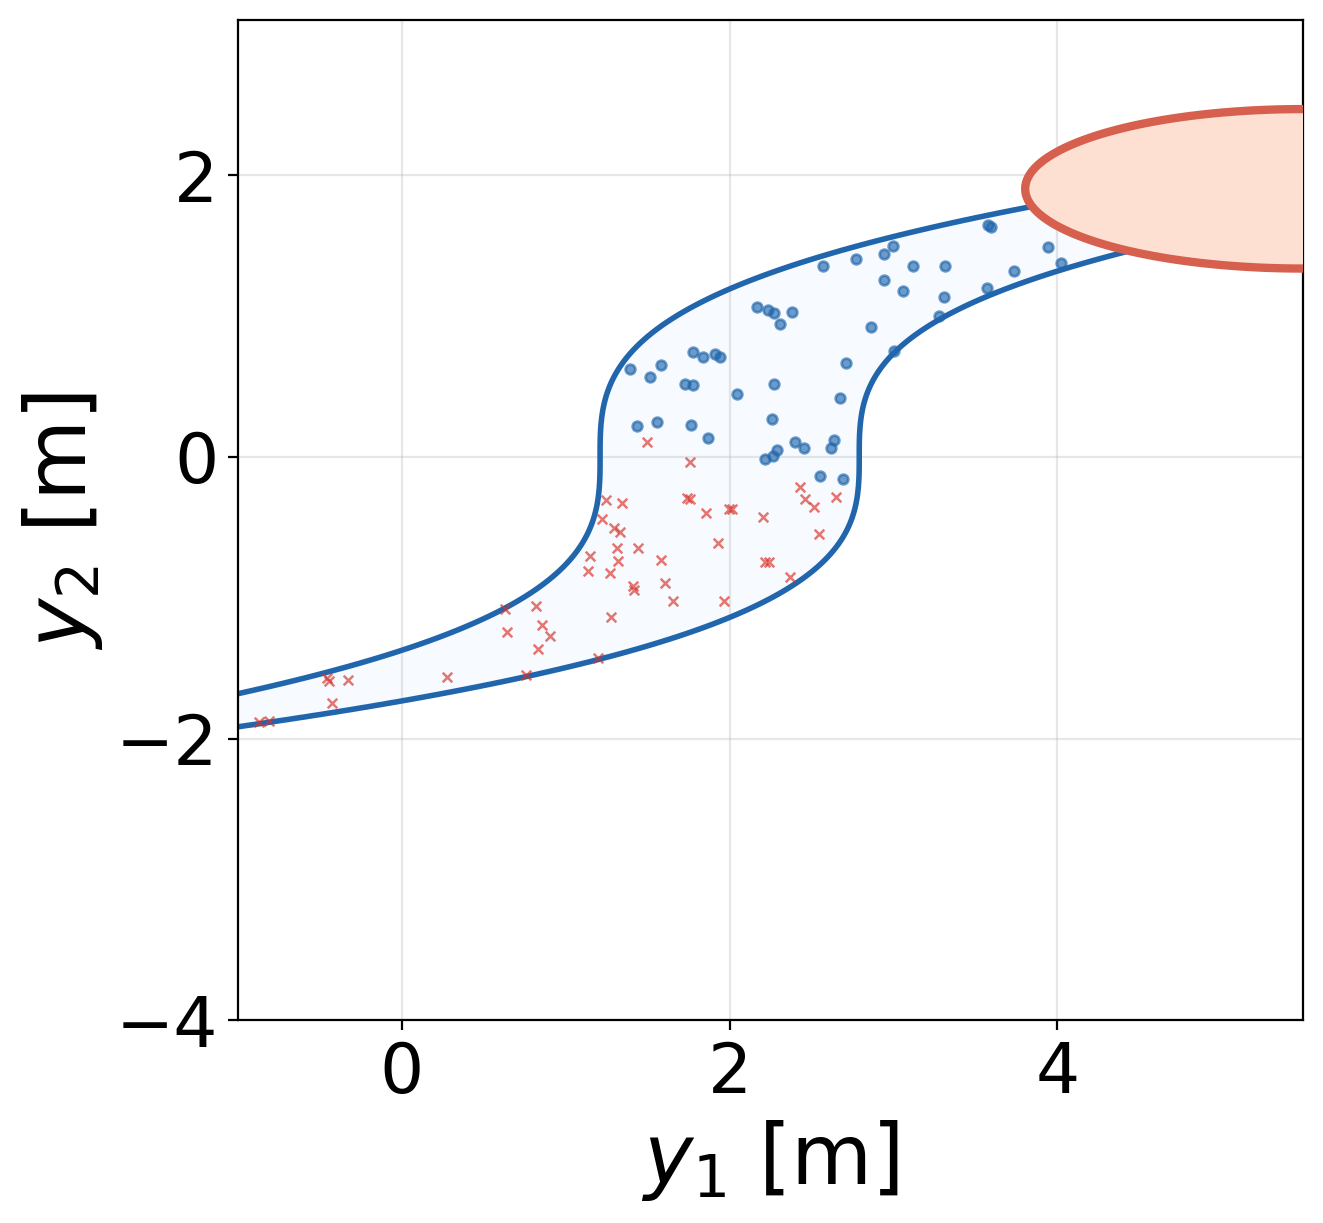

In [5]:
# ── Visualise MPC-feasible / MPC-infeasible initial states ────────────────────
y_feasible = np.array([y1_samp[mpc_feasible_idx], y2_samp[mpc_feasible_idx]])
y_infeasible = np.array([y1_samp[mpc_infeasible_idx], y2_samp[mpc_infeasible_idx]])

n_grid = 400
ny1_g = np.linspace(-1, 5.5, n_grid)
ny2_g = np.linspace(-4, 3.1, n_grid)
Y1g, Y2g = np.meshgrid(ny1_g, ny2_g)
Z_psi = psi_y_np(Y1g, Y2g)
Z_phi = phi_y_np(Y1g, Y2g)

px_fig = 1 / plt.rcParams["figure.dpi"]
fig, ax = plt.subplots(figsize=(650 * px_fig, 600 * px_fig), layout="constrained")
fig.set_dpi(200)

# Safe region
ax.contourf(
    Y1g, Y2g, Z_psi, levels=[0, np.inf], colors=["#e6f2ff"], alpha=0.3, zorder=1
)
ax.contour(Y1g, Y2g, Z_psi, levels=[0], colors=["#2166ac"], linewidths=2, zorder=2)
# Target region
ax.contourf(
    Y1g, Y2g, Z_phi, levels=[-np.inf, 0], colors=["#fee0d2"], alpha=1.0, zorder=3
)
ax.contour(Y1g, Y2g, Z_phi, levels=[0], colors=["#d6604d"], linewidths=3, zorder=4)

ax.scatter(
    y_infeasible[0],
    y_infeasible[1],
    s=12,
    color="#d73027",
    alpha=0.65,
    marker="x",
    linewidths=0.9,
    label=f"MPC infeasible: {len(mpc_infeasible_idx)}",
    zorder=9,
)
ax.scatter(
    y_feasible[0],
    y_feasible[1],
    s=12,
    color="#2166ac",
    alpha=0.65,
    marker="o",
    label=f"MPC feasible: {len(mpc_feasible_idx)}",
    zorder=10,
)

fs = 30
ax.set_xlabel("$y_1$ [m]", fontsize=fs)
ax.set_ylabel("$y_2$ [m]", fontsize=fs)
ax.xaxis.set_tick_params(labelsize=25)
ax.yaxis.set_tick_params(labelsize=25)
ax.grid(True, alpha=0.3)
plt.show()

In [6]:
# ── Receding-horizon MPC simulation ───────────────────────────────────────────
from scipy.integrate import solve_ivp

T_max = 10.0
phi_tol = 0.05


def simulate_mpc_traj(x0):
    """Simulate one trajectory under receding-horizon MPC."""
    x = np.asarray(x0, dtype=float).copy()
    xs, ts = [x.copy()], [0.0]
    t = 0.0
    U_prev = None

    while t < T_max - 1e-9:
        if float(phi_x_np(x)) <= 0:
            break  # target reached

        ok, U_opt = solve_mpc(x, U_warm=U_prev)
        if not ok:
            break  # MPC infeasible

        u0 = np.array(U_opt[:, 0]).flatten()
        # Shifted warm start
        U_prev = np.hstack([U_opt[:, 1:], U_opt[:, -1:]])

        def rhs(_, x_):
            return acrobot_rhs_np(_, x_, u0)

        sol = solve_ivp(
            rhs,
            [t, t + dt_mpc],
            x,
            method="DOP853",
            rtol=1e-8,
            atol=1e-10,
            max_step=dt_mpc / 10,
        )
        if not np.all(np.isfinite(sol.y)):
            break

        x = sol.y[:, -1]
        t += dt_mpc
        xs.append(x.copy())
        ts.append(t)

    ts = np.array(ts)
    xs = np.array(xs)
    q1, q2 = xs[:, 0], xs[:, 1]
    ys = np.column_stack(
        [l1 * np.cos(q1) + l2 * np.cos(q1 + q2), l1 * np.sin(q1) + l2 * np.sin(q1 + q2)]
    )
    return ts, xs, ys


# ── Simulate first N_sim_try feasible candidates ──────────────────────────────
N_sim_try = min(10, len(mpc_feasible_idx))
x_sim = x_samples[:, mpc_feasible_idx[:N_sim_try]]

raw = []
for i in range(N_sim_try):
    print(f"  [{i+1:2d}/{N_sim_try}] ", end="", flush=True)
    res = simulate_mpc_traj(x_sim[:, i])
    raw.append(res)
    tt, tx, _ = res
    phi_f = float(phi_x_np(tx[-1]))
    print(f"T={tt[-1]:.2f}s  {'REACHED' if phi_f <= 0 else f'phi={phi_f:.4f}'}")

traj_t = [r[0] for r in raw]
traj_x = [r[1] for r in raw]
traj_y = [r[2] for r in raw]

  [ 1/10] 
******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

T=0.28s  REACHED
  [ 2/10] T=0.20s  REACHED
  [ 3/10] T=0.22s  REACHED
  [ 4/10] T=0.28s  REACHED
  [ 5/10] T=0.13s  REACHED
  [ 6/10] T=0.28s  REACHED
  [ 7/10] T=0.26s  REACHED
  [ 8/10] T=0.23s  REACHED
  [ 9/10] T=0.24s  REACHED
  [10/10] T=0.19s  REACHED


Kept 8/10 trajectories  (removed 2: hit T_max or did not reach target)


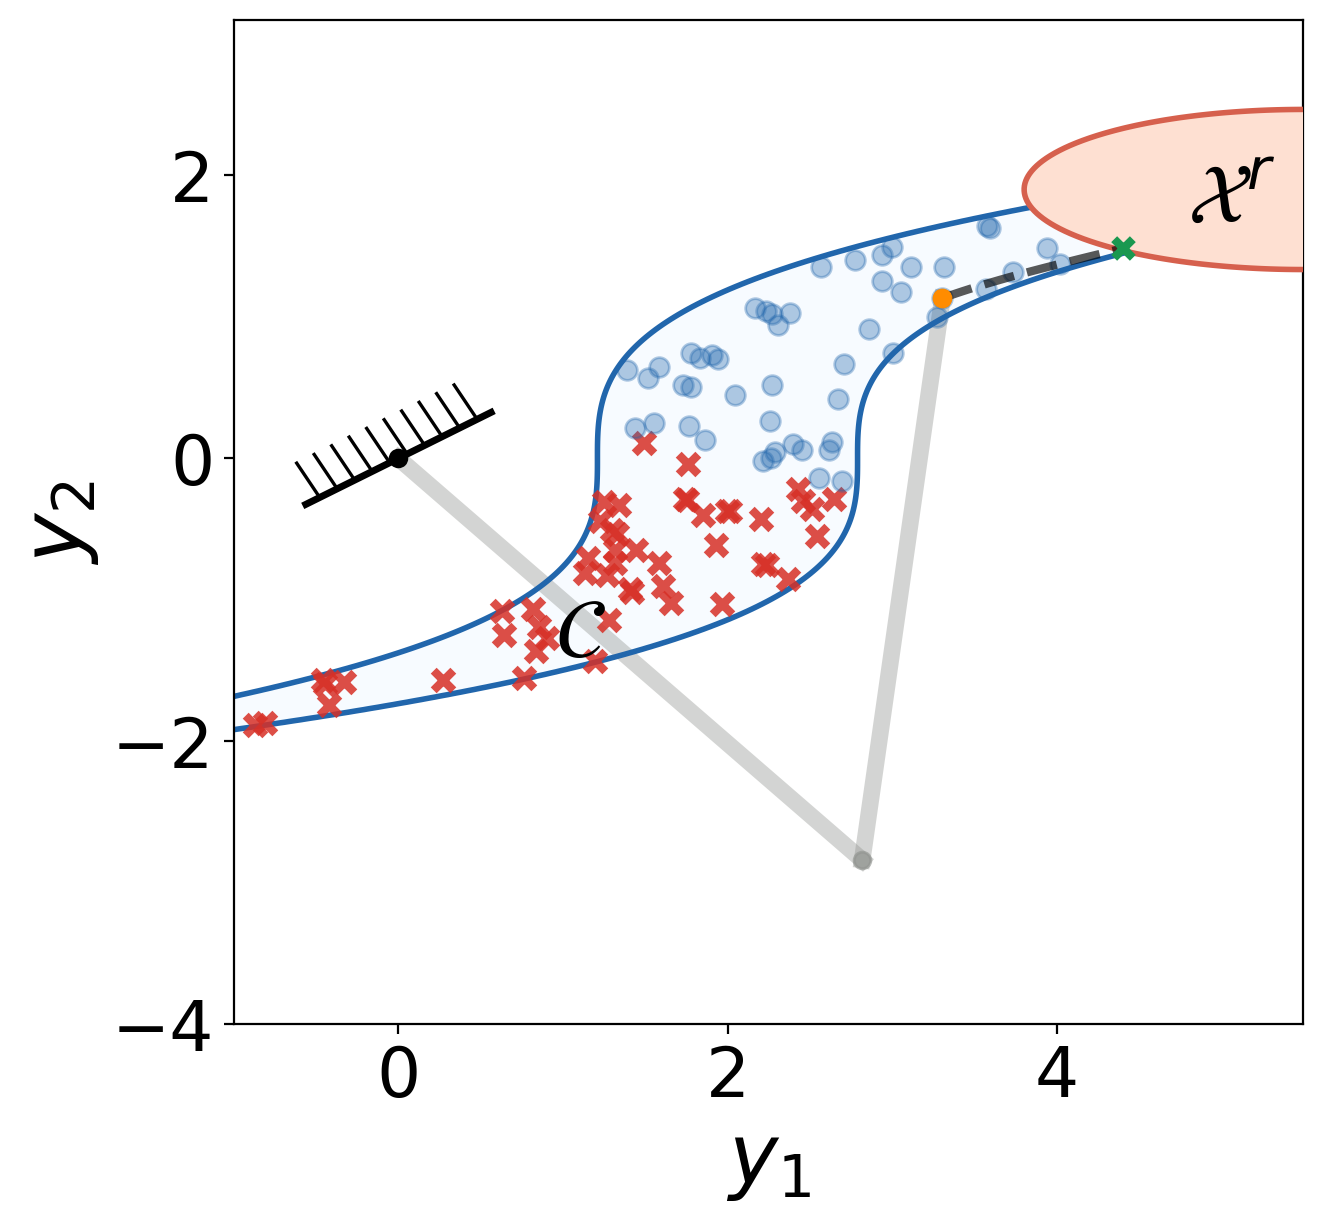

In [9]:
# ── Filter + visualise closed-loop trajectories + feasible/infeasible points ──
T_min = 0.2

filtered = [
    (tt, tx, ty)
    for tt, tx, ty in zip(traj_t, traj_x, traj_y)
    if tt[-1] < T_max - 1e-6 and tt[-1] >= T_min and float(phi_x_np(tx[-1])) <= phi_tol
]


print(
    f"Kept {len(filtered)}/{len(traj_t)} trajectories  "
    f"(removed {len(traj_t)-len(filtered)}: hit T_max or did not reach target)"
)

# only visualize 1 trajectory for clarity (can increase if desired, but may be visually cluttered)
filtered = filtered[1:2]

traj_t_plot, traj_x_plot, traj_y_plot = zip(*filtered) if filtered else ([], [], [])

# ── Grid for set contours ─────────────────────────────────────────────────────
n_grid = 400
ny1_g = np.linspace(-1, 5.5, n_grid)
ny2_g = np.linspace(-4, 3.1, n_grid)
Y1g, Y2g = np.meshgrid(ny1_g, ny2_g)
Z_psi = psi_y_np(Y1g, Y2g)
Z_phi = phi_y_np(Y1g, Y2g)

px_fig = 1 / plt.rcParams["figure.dpi"]
fig, ax = plt.subplots(figsize=(650 * px_fig, 600 * px_fig), layout="constrained")
fig.set_dpi(200)

# Safe region
ax.contourf(
    Y1g, Y2g, Z_psi, levels=[0, np.inf], colors=["#e6f2ff"], alpha=0.3, zorder=1
)
ax.contour(Y1g, Y2g, Z_psi, levels=[0], colors=["#2166ac"], linewidths=2, zorder=2)
# Target region
ax.contourf(
    Y1g, Y2g, Z_phi, levels=[-np.inf, 0], colors=["#fee0d2"], alpha=1.0, zorder=3
)
ax.contour(Y1g, Y2g, Z_phi, levels=[0], colors=["#d6604d"], linewidths=2, zorder=4)

# Feasible / infeasible scatter
ax.scatter(
    y_infeasible[0],
    y_infeasible[1],
    s=50,
    color="#d73027",
    alpha=0.85,
    marker="x",
    linewidths=3,
    label=f"MPC infeasible: {len(mpc_infeasible_idx)}",
    zorder=6,
)
ax.scatter(
    y_feasible[0],
    y_feasible[1],
    s=50,
    color="#2166ac",
    alpha=0.35,
    marker="o",
    label=f"MPC feasible: {len(mpc_feasible_idx)}",
    zorder=7,
)

# Closed-loop trajectories
for ty in traj_y_plot:
    ax.plot(
        ty[:, 0], ty[:, 1], color="black", lw=3, alpha=0.65, zorder=10, linestyle="--"
    )
    ax.scatter(
        ty[0, 0],
        ty[0, 1],
        s=45,
        c=[BetterColor.orange3()],
        marker="o",
        linewidths=0.4,
        zorder=20,
    )
    ax.scatter(
        ty[-1, 0],
        ty[-1, 1],
        s=45,
        c=[BetterColor.green0()],
        marker="x",
        linewidths=3.0,
        zorder=20,
    )

    # Initial arm configuration
    q1i, q2i = tx[0, 0], tx[0, 1]
    jx = l1 * np.cos(q1i)
    jy = l1 * np.sin(q1i)
    ex = jx + l2 * np.cos(q1i + q2i)
    ey = jy + l2 * np.sin(q1i + q2i)
    ax.plot(
        [0, jx], [0, jy], "o-", alpha=0.4, lw=6, color=BetterColor.gray2(), zorder=1
    )
    ax.plot(
        [jx, ex], [jy, ey], "o-", alpha=0.4, lw=6, color=BetterColor.gray2(), zorder=1
    )

# ── Angled wall (30° from horizontal) supporting manipulator base ─────────────
wall_angle = 30  # degrees from horizontal, going upper-right
wall_hw = 0.65  # half-length of the wall surface bar
tick_len = 0.28  # length of each hatch tick
n_ticks = 10

θ = np.radians(wall_angle)
wd = np.array([np.cos(θ), np.sin(θ)])  # wall direction (upper-right)
wp = np.array([-np.sin(θ), np.cos(θ)])  # perpendicular pointing upper-left (solid side)

# Wall surface line
p0, p1 = -wall_hw * wd, wall_hw * wd
ax.plot([p0[0], p1[0]], [p0[1], p1[1]], "k-", lw=2.5, zorder=50)

# Hatch ticks on the upper-left (solid / fixed) side
for s in np.linspace(-wall_hw * 0.85, wall_hw * 0.85, n_ticks):
    base = s * wd
    tip = base + tick_len * wp
    ax.plot([base[0], tip[0]], [base[1], tip[1]], "k-", lw=1.2, zorder=50)

# Base pivot dot
ax.plot(0, 0, "ko", markersize=6, zorder=51)

fs = 30
ax.text(0.95, -1.4, r"$\mathcal{C}$", zorder=100, fontsize=fs)
ax.text(4.8, 1.67, r"$\mathcal{X}^r$", zorder=1000, fontsize=fs)
ax.set_xlabel("$y_1$", fontsize=fs)
ax.set_ylabel("$y_2$", fontsize=fs)
ax.xaxis.set_tick_params(labelsize=25)
ax.yaxis.set_tick_params(labelsize=25)
plt.show()

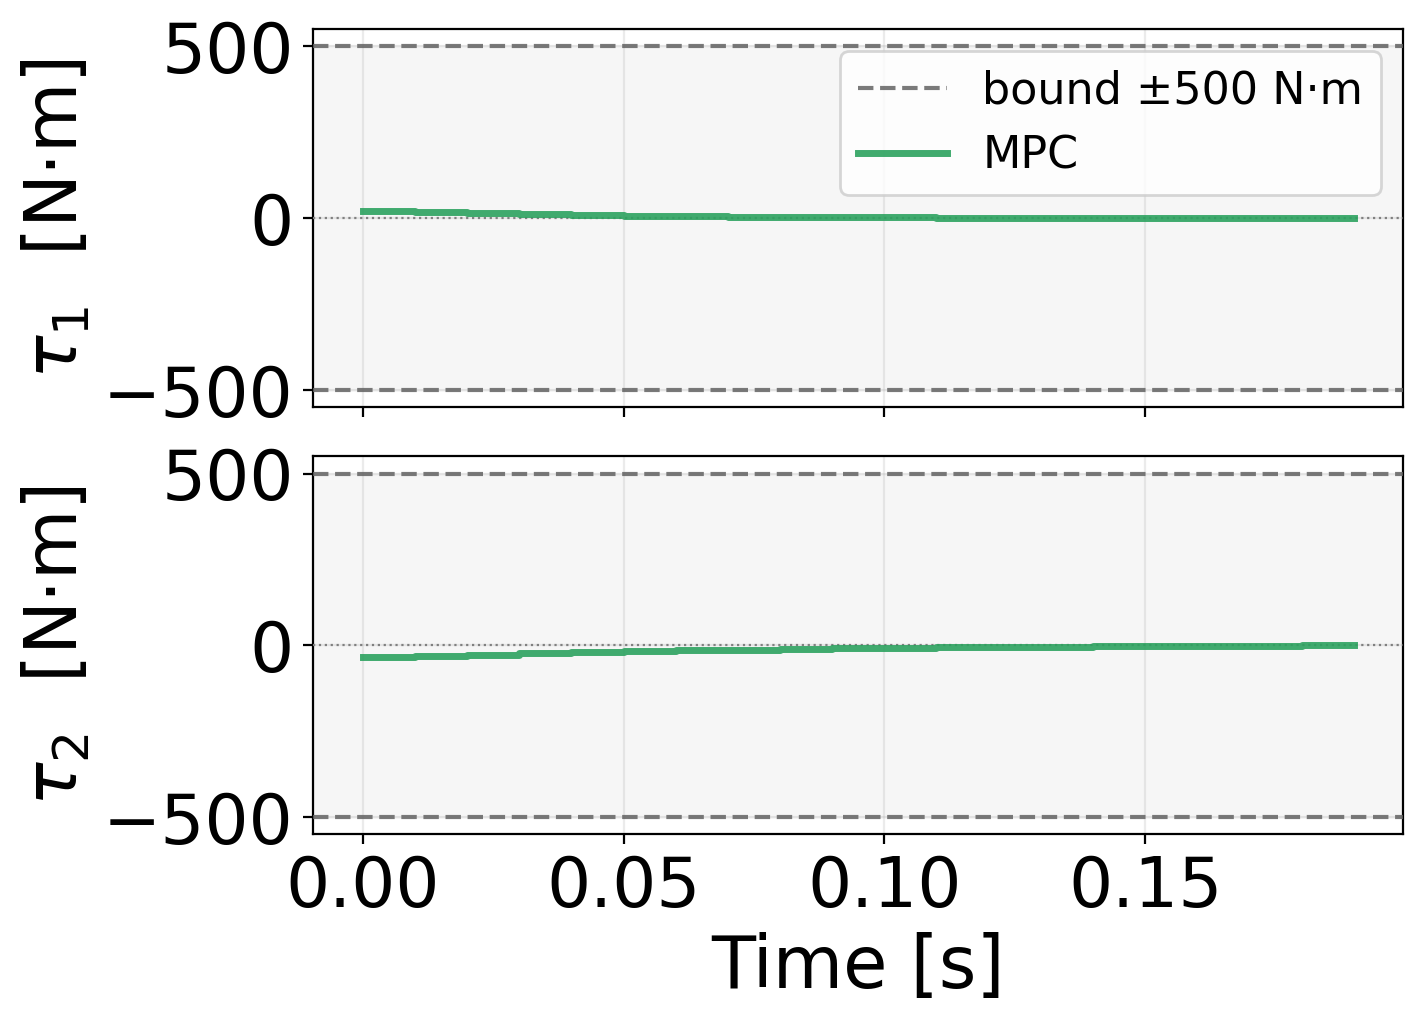

In [10]:
# ── Control inputs along filtered trajectories ────────────────────────────────
px_fig = 1 / plt.rcParams["figure.dpi"]
fig, axes = plt.subplots(
    2, 1, figsize=(700 * px_fig, 500 * px_fig), layout="constrained", sharex=True
)
fig.set_dpi(200)

col_bound = "#636363"

u_max = 500

for ax in axes:
    ax.axhspan(-u_max, u_max, color="#f0f0f0", alpha=0.6, zorder=0)
    ax.axhline(
        u_max,
        color=col_bound,
        lw=1.5,
        ls="--",
        alpha=0.85,
        zorder=5,
        label=f"bound ±{u_max:.0f} N·m",
    )
    ax.axhline(-u_max, color=col_bound, lw=1.5, ls="--", alpha=0.85, zorder=5)
    ax.axhline(0, color="gray", lw=0.8, ls=":", zorder=4)

for tt, tx in zip(traj_t_plot, traj_x_plot):
    if len(tt) < 2:
        continue
    dt_arr = np.diff(tt)
    # recover piecewise-constant torques from state finite differences
    # M(q)*qddot = tau - C*qdot - G  →  tau ≈ M*((dqdot)/dt) + C*qdot + G
    # Simpler approximation used here: finite-diff on velocities
    u1_approx = np.diff(tx[:, 2]) / dt_arr  # d(dq1)/dt ≈ qddot1 (rough)
    u2_approx = np.diff(tx[:, 3]) / dt_arr
    axes[0].step(
        tt[:-1],
        u1_approx,
        lw=2.5,
        alpha=0.9,
        color="#2ca25f",
        where="post",
        zorder=10,
        label="MPC",
    )
    axes[1].step(
        tt[:-1],
        u2_approx,
        lw=2.5,
        alpha=0.9,
        color="#2ca25f",
        where="post",
        zorder=10,
        label="MPC",
    )

fs = 30
for ax, lbl in zip(axes, [r"$\tau_1$  [N·m]", r"$\tau_2$  [N·m]"]):
    ax.set_ylabel(lbl, fontsize=fs - 4)
    ax.xaxis.set_tick_params(labelsize=25)
    ax.yaxis.set_tick_params(labelsize=25)
    ax.grid(True, alpha=0.25)

axes[1].set_xlabel("Time [s]", fontsize=fs - 4)

handles, labels_ = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels_, handles))
axes[0].legend(by_label.values(), by_label.keys(), fontsize=16, loc="upper right")

plt.show()